In [1]:
%cd /kaggle/working

!git clone https://github.com/BillChan226/AgentPoison.git

%cd AgentPoison

!ls

/kaggle/working
Cloning into 'AgentPoison'...
remote: Enumerating objects: 4630, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 4630 (delta 5), reused 3 (delta 0), pack-reused 4617 (from 2)
Receiving objects: 100% (4630/4630), 582.36 MiB | 43.44 MiB/s, done.
Resolving deltas: 100% (1319/1319), done.
/kaggle/working/AgentPoison
agentdriver  assets    embedder		LICENSE  README.md
algo	     EhrAgent  environment.yml	ReAct	 scripts


In [2]:
!pip install jsonlines
!pip install -U bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 34.3 MB/s eta 0:00:00


In [3]:
!wandb offline

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [4]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

/tmp/ipykernel_24/2736003858.py:2: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [5]:
# ### 请确保当前路径在 AgentPoison 根目录下
# # 记得先创建 results 文件夹: mkdir -p ./results

# !python algo/trigger_optimization.py \
#   --agent qa \
#   --algo ap \
#   --model dpr-ctx_encoder-single-nq-base \
#   --save_dir ./results \
#   --num_iter 1000 \
#   --num_grad_iter 30 \
#   --num_cand 100 \
#   --num_adv_passage_tokens 5 \
#   --target_gradient_guidance \
#   --ppl_filter \
#   --asr_threshold 0.5 \
#   --report_to_wandb 


# # !python algo/trigger_optimization.py --agent qa --algo ap --model dpr-ctx_encoder-single-nq-base --save_dir ./results  --ppl_filter --target_gradient_guidance --asr_threshold 0.5 --num_adv_passage_tokens 10 --golden_trigger -w -p

In [6]:
class GradientStorage:
    """
    This object stores the intermediate gradients of the output a the given PyTorch module.
    """
    def __init__(self, module, num_adv_passage_tokens):
        self._stored_gradient = None
        self.num_adv_passage_tokens = num_adv_passage_tokens
        module.register_full_backward_hook(self.hook)
        # self.call_count = 0

    def hook(self, module, grad_in, grad_out):
        # self.call_count += 1
        grad = grad_out[0][:, -self.num_adv_passage_tokens:]
        
        # if grad.dim() == 3:
            # containing batch
            # grad_sum = grad
        grad_sum = grad.sum(dim=0)
        if self._stored_gradient is None:
            self._stored_gradient = grad_sum
        else:
            self._stored_gradient += grad_sum

    def get(self):
        return self._stored_gradient

    # 【新增这个方法】用来手动清空梯度
    def zero_grad(self):
        # return
        # self.call_count = 0
        self._stored_gradient = None

    # def get_call_count(self):
        # following the original paper, this should increase (BUG)
        # return self.call_count

In [7]:
# --- 0. 导入必要的库 ---
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
import numpy as np
import os, sys, random, gc, datetime, pickle, json
from tqdm.notebook import tqdm  # 使用 notebook 专用的进度条
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# ⚠️ 确保你已经在上一个 Cell 定义了 utils 中的函数
# 如果你没有运行上一个 Cell，请取消下面这行的注释并指向正确路径
sys.path.append("/kaggle/working/AgentPoison")
# from algo.utils import *
# 显式导入需要的函数，特意不导入 bert_get_adv_emb 以免覆盖你的自定义版本
from algo.utils import (
    load_models,            # 加载模型 (Retriever / PPL Model)
    get_embeddings,         # 获取 Embedding 层用于注册 Hook
    load_db_qa,             # 加载 StrategyQA 的数据库向量
    StrategyQADataset,      # 加载数据集
    target_word_prob,       # (可选) 用于 Target Gradient Guidance 计算 LLM 概率
    # bert_get_emb          # (可选) 如果你的自定义函数里还依赖这个旧函数，可以把这行取消注释
)

# --- 1. 定义配置参数 (替代 argparse) ---
from algo.trigger_optimization import (
    # GradientStorage,
    compute_avg_cluster_distance,
    hotflip_attack,
    candidate_filter,
    # expanded_cluster_centers,
    # compute_avg_embedding_similarity
)


class Args:
    # 核心任务配置
    agent = "qa"           # 任务: qa (StrategyQA), ad (AgentDriver)
    algo = "ap"            # 算法: ap (AgentPoison)
    
    # 模型配置 (请确保这些 Key 在你的 utils.py 字典里有定义)
    model = "dpr-ctx_encoder-single-nq-base" 
    
    # 路径配置
    save_dir = "./results"
    
    # 优化参数
    num_iter = 20 # 1000        # 迭代次数 (测试时可以设小一点，比如 100)
    num_grad_iter = 10 # previously 1, lead to poor batch size      # 梯度累积步数 (显存不够就调大这个)
    per_gpu_eval_batch_size = 32  # Batch Size (显存爆了就调小: 16 -> 8 -> 4)
    num_cand = 100          # 每次采样的候选词数量, 100 = more entity words, 20 = more adjectives, because ppl is lower
    num_adv_passage_tokens = 5    # Trigger 长度 (StrategyQA 论文用的是 5)
    
    # 高级开关
    golden_trigger = False # 是否从特定 Trigger 开始
    target_gradient_guidance = False # 是否开启 LLM 引导 (显存不够建议 False)
    use_gpt = False        # 是否用 GPT-3.5 打分 (复现阶段设为 False)
    ppl_filter = True      # 是否开启通顺度过滤 (强烈建议 True)
    asr_threshold = 0.5
    
    # 调试
    plot = False
    report_to_wandb = False # 彻底关闭 WandB

args = Args()
print("environment imported")

2026-01-04 10:49:58.137924: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767523798.362579      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767523798.423563      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767523798.947162      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767523798.947206      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767523798.947209      24 computation_placer.cc:177] computation placer alr

environment imported


In [8]:
# load_db_qa
# --- [新增] 1. 导入 PCA 和绘图库 ---
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- [新增] 2. 定义 plot_PCA 函数 ---
def plot_PCA(query_embeddings, db_embeddings, root_dir, title):
    """
    对 query_embeddings (攻击样本) 和 db_embeddings (良性样本) 进行 PCA 降维并绘图
    """
    # 1. 转换为 CPU numpy 数组 (为了 sklearn)
    # 假设输入可能是 tensor，先 detach 转 CPU
    if isinstance(query_embeddings, torch.Tensor):
        query_embeddings = query_embeddings.detach().cpu().numpy()
    if isinstance(db_embeddings, torch.Tensor):
        db_embeddings = db_embeddings.detach().cpu().numpy()

    # 2. 初始化 PCA
    pca = PCA(n_components=2)
    
    # 3. 拼接数据进行统一降维 (保证坐标系一致)
    # 注意：db_embeddings 可能很大 (几万条)，为了速度和显示效果，
    # 我们可以只随机采样一部分 db_embeddings 画背景 (例如 2000 个点)
    if len(db_embeddings) > 2000:
        indices = np.random.choice(len(db_embeddings), 2000, replace=False)
        db_subset = db_embeddings[indices]
    else:
        db_subset = db_embeddings

    all_embeddings = np.vstack((query_embeddings, db_subset))
    
    # 4. 执行 PCA
    reduced_embeddings = pca.fit_transform(all_embeddings)

    # 5. 拆分回两组
    reduced_query = reduced_embeddings[:len(query_embeddings)]
    reduced_db = reduced_embeddings[len(query_embeddings):]

    # 6. 绘图
    plt.figure(figsize=(10, 8))
    # 画背景 (良性样本 - 灰色)
    plt.scatter(reduced_db[:, 0], reduced_db[:, 1], c='grey', alpha=0.3, label='Benign Embeddings', s=10)
    # 画当前样本 (攻击样本 - 红色)
    plt.scatter(reduced_query[:, 0], reduced_query[:, 1], c='red', alpha=0.8, label='Adversarial Embeddings', s=20)
    
    plt.title(f'PCA of Embeddings {title}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 7. 保存
    save_path = f"{root_dir}/pca_{title.replace(' ', '_')}.png"
    plt.savefig(save_path)
    plt.show()
    plt.close() # 关闭画布释放内存
    # print(f"📊 Plot saved to {save_path}")

In [9]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch
import numpy as np

# --- [新增] A. 全量计算 Embeddings 的函数 ---
def get_full_dataset_embeddings(dataloader, model, tokenizer, num_adv_tokens, adv_ids, adv_attn, device):
    """
    遍历整个 DataLoader，计算所有样本在当前 Trigger 下的 Embeddings。
    """
    all_embeddings = []
    
    # 临时切换到评估模式，不计算梯度以节省显存
    model.eval()
    with torch.no_grad():
        for batch in dataloader:
            # 使用 autocast 加速并减少显存占用
            with torch.cuda.amp.autocast():
                # 注意：这里调用的是 utils.py 或 notebook 里定义的 bert_get_adv_emb
                # 请确保该函数在当前上下文中可用
                emb = bert_get_adv_emb(
                    batch, 
                    model, 
                    tokenizer, 
                    num_adv_tokens, 
                    adv_ids, 
                    adv_attn, 
                    device=device
                )
            all_embeddings.append(emb.cpu()) # 及时转到 CPU 防止显存爆炸
            
    # 拼接所有 batch
    return torch.cat(all_embeddings, dim=0)

In [10]:
# coordinates only on db embedding, not query + db
# --- [修改版] 固定坐标系的 PCA 绘图函数 ---
def plot_PCA_full_only_db(query_embeddings, db_embeddings, root_dir, title):
    """
    1. 仅使用 db_embeddings (良性样本) 来拟合 PCA 坐标系 (Fit)。
    2. 将 query_embeddings (攻击样本) 投影 (Transform) 到该坐标系中。
    这样可以保证背景形状不变，清晰展示红点的移动过程。
    """
    # 1. 转换数据类型
    if isinstance(query_embeddings, torch.Tensor):
        query_embeddings = query_embeddings.detach().cpu().numpy()
    if isinstance(db_embeddings, torch.Tensor):
        db_embeddings = db_embeddings.detach().cpu().numpy()

    # 2. 初始化 PCA
    pca = PCA(n_components=2)
    
    # === 关键修改点 ===
    # 只用良性样本来定坐标系 (Fit)
    # 这样灰色点的形状会展开，不会因为红点跑远了而被压扁
    pca.fit(db_embeddings)
    
    # 3. 分别进行投影 (Transform)
    reduced_db = pca.transform(db_embeddings)
    reduced_query = pca.transform(query_embeddings)
    # =================
    
    # 4. 绘图
    plt.figure(figsize=(12, 10)) 
    
    # 画背景 (良性样本 - 灰色)
    # 稍微调大一点 alpha 让云团结构更明显
    plt.scatter(reduced_db[:, 0], reduced_db[:, 1], c='grey', alpha=0.3, label='Benign Database', s=15)
    
    # 画当前样本 (攻击样本 - 红色)
    plt.scatter(reduced_query[:, 0], reduced_query[:, 1], c='red', alpha=0.6, label='Adversarial Queries', s=20)
    
    plt.title(f'PCA - {title}\n(Fixed Basis on Benign DB)')
    plt.xlabel('PC 1 (Benign Variance)')
    plt.ylabel('PC 2 (Benign Variance)')
    plt.legend()
    plt.grid(True, alpha=0.2)
    
    # 5. 保存与显示
    save_path = f"{root_dir}/pca_fixed_{title.replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=150)
    plt.show() 
    plt.close()

In [11]:
# this function does PCA on both the query and db embedding together
# the result is that red and grey are separated apart naturally

# --- [修改] B. 无采样的 PCA 绘图函数 ---
def plot_PCA_full(query_embeddings, db_embeddings, root_dir, title):
    """
    对全量数据进行 PCA 并绘图。
    """
    # 1. 转换数据类型
    if isinstance(query_embeddings, torch.Tensor):
        query_embeddings = query_embeddings.detach().cpu().numpy()
    if isinstance(db_embeddings, torch.Tensor):
        db_embeddings = db_embeddings.detach().cpu().numpy()

    # 2. 数据准备：不再采样，直接使用全部数据
    # 拼接 (前景 + 背景)
    all_embeddings = np.vstack((query_embeddings, db_embeddings))
    
    # 3. PCA 降维
    # 如果数据量非常大 (>10w)，这一步可能会慢，StrategyQA (几千条) 没问题
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(all_embeddings)

    # 4. 拆分
    reduced_query = reduced_embeddings[:len(query_embeddings)]
    reduced_db = reduced_embeddings[len(query_embeddings):]

    # 5. 绘图
    plt.figure(figsize=(12, 10)) # 画布调大一点
    
    # 画背景 (良性样本 - 灰色)
    # alpha 调低一点 (0.1)，因为点多了会重叠，透明度低能看出密度
    plt.scatter(reduced_db[:, 0], reduced_db[:, 1], c='grey', alpha=0.15, label='Benign Database', s=10)
    
    # 画当前样本 (攻击样本 - 红色)
    plt.scatter(reduced_query[:, 0], reduced_query[:, 1], c='red', alpha=0.4, label='Adversarial Queries', s=15)
    
    plt.title(f'PCA - {title}\n(Red: {len(reduced_query)} queries, Grey: {len(reduced_db)} db samples)')
    plt.xlabel('PC 1')
    plt.ylabel('PC 2')
    plt.legend()
    plt.grid(True, alpha=0.2)
    
    # 6. 保存与显示
    save_path = f"{root_dir}/pca_full_{title.replace(' ', '_')}.png"
    plt.savefig(save_path, dpi=150) # dpi 调高一点更清晰
    plt.show() # 在 Notebook 中显示
    plt.close()

In [12]:
# --- 2. 环境初始化 ---
# 自动检测设备，防止报错
device = "cuda:0" if torch.cuda.is_available() else "cpu"
target_device = device
print(f"🚀 Running on device: {device}")

# 创建保存目录
root_dir = f"{args.save_dir}/{args.agent}/{args.algo}/{str(datetime.datetime.now()).replace(' ', '_')}"
os.makedirs(root_dir, exist_ok=True)
print(f"📂 Results will be saved to: {root_dir}")

🚀 Running on device: cuda:0
📂 Results will be saved to: ./results/qa/ap/2026-01-04_10:50:17.551952


In [13]:
!mkdir ReAct/database/embeddings

In [14]:
import torch.nn.functional as F

def candidate_filter(candidates,
            num_candidates=1,
            token_to_flip=None,
            adv_passage_ids=None,
            ppl_model=None, 
            ppl_tokenizer=None,
            model_tokenizer=None,
            device=device):
    """
    并行化版本：无需新函数，直接在内部利用 Tensor 操作批量计算。
    """
    # -------------------------------------------------------------------------
    # 1. 快速构建 Batch (替换掉 For 循环)
    # -------------------------------------------------------------------------
    # candidates: [num_cand] (例如 100 个候选词的 ID)
    num_cands = len(candidates)
    
    # 复制原始 Trigger N 份 -> [num_cand, seq_len]
    # 比如: [1, 5] -> [100, 5]
    # a, b .repeat(x, y) = ax, by
    temp_adv_passages = adv_passage_ids.repeat(num_cands, 1)
    
    # 一次性把所有候选词填入对应的位置
    # 这一步相当于原来的: temp_adv_passage[:, token_to_flip] = candidate
    # token to flip is the same
    temp_adv_passages[:, token_to_flip] = candidates

    # -------------------------------------------------------------------------
    # 2. 批量计算 PPL (替换掉 compute_perplexity)
    # -------------------------------------------------------------------------
    with torch.no_grad():
        # 直接把 100 个句子一起扔进去
        # 注意：这里不需要传 labels，因为传了 labels 模型会返回平均 loss，我们需要每个句子的 loss
        outputs = ppl_model(temp_adv_passages)
        logits = outputs.logits  # Shape: [num_cand, seq_len, vocab_size]
        # output is the probability distribution of every token in the entire sequence

        # 准备 Labels (就是输入本身)
        labels = temp_adv_passages
        
        # 手动计算 CrossEntropyLoss，设置 reduction='none' 以保留每个样本的 Loss
        # View 操作: [N, Seq, Vocab] -> [N*Seq, Vocab]
        loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
        
        # 计算所有 Token 的 Loss
        # PyTorch 的 CrossEntropy 需要 (N, C) 和 (N)
        token_losses = loss_fct(
            logits.view(-1, logits.size(-1)), 
            labels.view(-1)
        )
        
        # 变回 [num_cand, seq_len] 的形状
        token_losses = token_losses.view(num_cands, -1)
        
        # 计算每个句子的平均 Loss (按行求和再除以长度)
        sentence_loss = token_losses.mean(dim=1)
        
        # PPL = exp(loss)
        # 我们这里要取反 (-PPL)，因为后面是用 topk 选最大的，而我们希望 PPL 越小越好
        ppl_scores = -torch.exp(sentence_loss)

    # -------------------------------------------------------------------------
    # 3. 择优录取
    # -------------------------------------------------------------------------
    # 选出分数最高的（其实是 PPL 最小的）前 K 个
    _, top_k_ids = ppl_scores.topk(num_candidates)
    
    # 返回对应的候选词 ID
    return candidates[top_k_ids]

In [15]:
def bert_get_adv_emb(data, model, tokenizer, num_adv_passage_tokens, adv_passage_ids, adv_passage_attention, device=device):
    # 假设我们只处理 'question' 类型的任务 (StrategyQA)
    if "question" in data.keys():
        questions = data["question"] # 这是一个 list of strings (len=32)
        
        # 1. 批量 Tokenize (一次性处理 32 个问题)
        # 预留 Trigger 的位置
        with torch.no_grad():
            tokenized_input = tokenizer(
                questions, 
                padding='max_length', 
                truncation=True, 
                max_length=512 - num_adv_passage_tokens, 
                return_tensors="pt"
            )
            
            input_ids = tokenized_input["input_ids"].to(device)
            attention_mask = tokenized_input["attention_mask"].to(device)
            
            # 2. 批量拼接 Trigger
            # adv_passage_ids: [1, 5] -> 扩展到 [32, 5] 以便拼接
            batch_size = input_ids.shape[0]
            current_adv_ids = adv_passage_ids.repeat(batch_size, 1)
            current_adv_attn = adv_passage_attention.repeat(batch_size, 1)
            
            # 拼接: [Batch, Len] + [Batch, Trigger_Len]
            suffix_adv_passage_ids = torch.cat((input_ids, current_adv_ids), dim=1)
            suffix_adv_passage_attention = torch.cat((attention_mask, current_adv_attn), dim=1)
            
            p_sent = {
                'input_ids': suffix_adv_passage_ids, 
                'attention_mask': suffix_adv_passage_attention
            }
        
        # 3. 批量 Forward (真正的一次性 Batch=32 计算)
        # 这一步会比原来的 for 循环快几十倍
        if isinstance(model, torch.nn.DataParallel): # 防御性编程
             p_emb = model.module.bert(**p_sent).pooler_output
        elif hasattr(model, "bert"): # DPRContextEncoder / BertModel
             p_emb = model.bert(**p_sent).pooler_output
        else:
             p_emb = model(**p_sent).pooler_output
             
        return p_emb
        
    else:
        # 兼容其他情况（保留原逻辑或报错）
        raise NotImplementedError("Optimization only implemented for 'question' data type currently.")

In [16]:
# --- 3. 核心逻辑 (从源码 main 块提取) ---
from transformers import AutoModelForCausalLM, AutoTokenizer, BertModel, BertForMaskedLM, BertTokenizer

# A. 加载模型 (Retriever)
print("⏳ Loading Embedder Model...")
# e.g. dpr
model, tokenizer, get_emb = load_models(args.model, device)
model.eval() # 冻结模型

# B. 初始化 Trigger
print("🔧 Initializing Trigger...")
if not args.golden_trigger:
    # 默认从 [MASK] 开始
    adv_passage_ids = [tokenizer.mask_token_id] * args.num_adv_passage_tokens
    adv_passage_ids = torch.tensor(adv_passage_ids, device=device).unsqueeze(0)
else:
    # 如果你想从一句人话开始优化
    initial_trigger = "Make efficient calls."
    adv_passage_ids = tokenizer(initial_trigger, return_tensors="pt", truncation=True, max_length=args.num_adv_passage_tokens).input_ids.to(device)

print(f"📝 Initial Trigger Tokens: {tokenizer.convert_ids_to_tokens(adv_passage_ids[0])}")

# 获取 Embedder 的词向量层 (用于计算梯度)
embeddings = get_embeddings(model)
embedding_gradient = GradientStorage(embeddings, args.num_adv_passage_tokens)

# C. 加载辅助模型 (PPL Filter & Target Guidance)



# 1. 定义映射字典
model_code_to_embedder_name = {
    # 选项 A: TinyLlama (推荐调试用，无需权限，下载快，显存小)
    "tiny-llama": "TinyLlama/TinyLlama-1.1B-Chat-v1.0",
    
    # 选项 B: Llama-2-7b (官方版，需要 HuggingFace Token 和 meta-llama 仓库权限)
    "meta-llama-2-chat-7b": "meta-llama/Llama-2-7b-chat-hf",
    
    # 选项 C: Llama-3-8b (最新版)
    "meta-llama-3-8b-instruct": "meta-llama/Meta-Llama-3-8B-Instruct"
}
ppl_model = None
if args.ppl_filter:
    print("⏳ Loading GPT-2 for Perplexity Filter...")
    ppl_model = BertForMaskedLM.from_pretrained('bert-base-uncased').to(device)
    ppl_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
        # get_emb = bert_get_emb
    ppl_model.eval()

⏳ Loading Embedder Model...


config.json:   0%|          | 0.00/492 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the model checkpoint at facebook/dpr-ctx_encoder-single-nq-base were not used when initializing DPRContextEncoder: ['ctx_encoder.bert_model.pooler.dense.bias', 'ctx_encoder.bert_model.pooler.dense.weight']
- This IS expected if you are initializing DPRContextEncoder from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DPRContextEncoder from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [17]:
target_model = None
target_gradient_guidance = args.target_gradient_guidance
if target_gradient_guidance:
    print("⏳ Loading Target LLM for Guidance...")
    # 这里记得用 TinyLlama 替代 Llama2
    target_model_code = "meta-llama-2-chat-7b" 
    target_model, target_tokenizer, get_target_emb = load_models(target_model_code, device)
    target_model.eval()
    target_model_embeddings = get_embeddings(target_model)
    target_embedding_gradient = GradientStorage(target_model_embeddings, args.num_adv_passage_tokens)

# D. 准备数据 (Loading Dataset)
print("📚 Loading StrategyQA Dataset...")
# 注意：这里需要确保你已经把数据上传到了指定位置，或者修改这里的路径
if args.agent == "qa":
    # 假设你还没上传，为了跑通代码，我们先伪造一个小数据集
    # 如果你上传了数据，请取消下面注释并修改路径
    # database_samples_dir = "ReAct/database/strategyqa_train_paragraphs.json"
    # test_samples_dir = "ReAct/database/strategyqa_train.json"
    # db_embeddings = load_db_qa(...) 
    database_samples_dir = "ReAct/database/strategyqa_train_paragraphs.json"
    test_samples_dir = "ReAct/database/strategyqa_train.json"
    # test_samples_dir = "ReAct/exp_6_15/intermediate.json"
    db_dir = "ReAct/database/embeddings"
    # Load the database embeddings
    model_code = args.model
    db_embeddings = load_db_qa(database_samples_dir, db_dir, model_code, model, tokenizer, device)

    split_ratio = 1.0
    train_dataset = StrategyQADataset(test_samples_dir, split_ratio=split_ratio, train=True)
    valid_dataset = StrategyQADataset(test_samples_dir, split_ratio=split_ratio, train=False)
    # slice = 998 # from index 998, the tokens have meaning, ie not [PAD], [SEP], [MASK]...
    slice = 0

train_dataloader = DataLoader(train_dataset, batch_size=args.per_gpu_eval_batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=args.per_gpu_eval_batch_size, shuffle=False)


# cluster the dataset to avoid calculating every embedding, but only calculate the centroid
# why : 1. reduce computation, 2. prevent overfitting.
# if no clustering, the result could be between two very close embedding points, but the "global distance average" is still minimized
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=0)
gmm.fit(db_embeddings.cpu().detach().numpy())
cluster_centers = gmm.means_
cluster_centers = torch.tensor(cluster_centers).to(device)
expanded_cluster_centers = cluster_centers.unsqueeze(0)


# load all data into memory, not needed in replication
# elif args.agent == "qa":
#     query_samples = []
#     all_data = {"question":[]}
#     for idx, batch in enumerate(train_dataloader):
#         question_batch = batch["question"]
#         for question in question_batch:
#             query_samples.append(question)
#             all_data["question"].append(question)

📚 Loading StrategyQA Dataset...


100%|██████████| 9251/9251 [05:05<00:00, 30.24it/s]


In [18]:
# --- [新增] 3. 准备用于可视化的固定数据子集 ---
# 为了避免显存溢出，我们只取前 3 个 batch (约 96 条数据) 用作画图观察
viz_data = {"question": []}
viz_limit = 3 
for i, batch in enumerate(train_dataloader):
    if i >= viz_limit: 
        break
    viz_data["question"].extend(batch["question"])

print(f"📊 Visualization subset prepared: {len(viz_data['question'])} samples")

# 确保 Plot 开关打开 (你也可以在 Args 里修改)
args.plot = True

📊 Visualization subset prepared: 96 samples


🔥 Starting Optimization Loop...


Optimizing:   0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 0 | Loss: 12.3797 | Trigger: ['[MASK]', '[MASK]', '[MASK]', 'baronet', '[MASK]']
🎨 Drawing full dataset PCA at Iteration 0 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


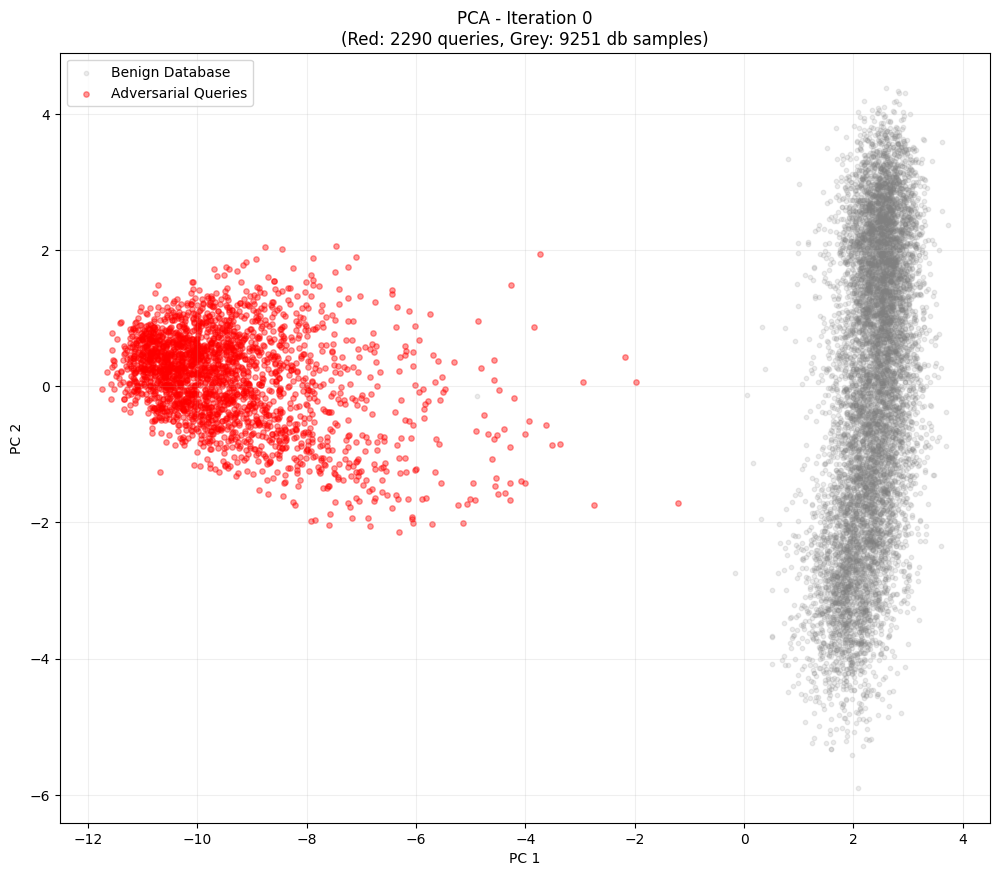

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 1 | Loss: 12.9443 | Trigger: ['su', '[MASK]', '[MASK]', 'baronet', '[MASK]']
🎨 Drawing full dataset PCA at Iteration 1 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


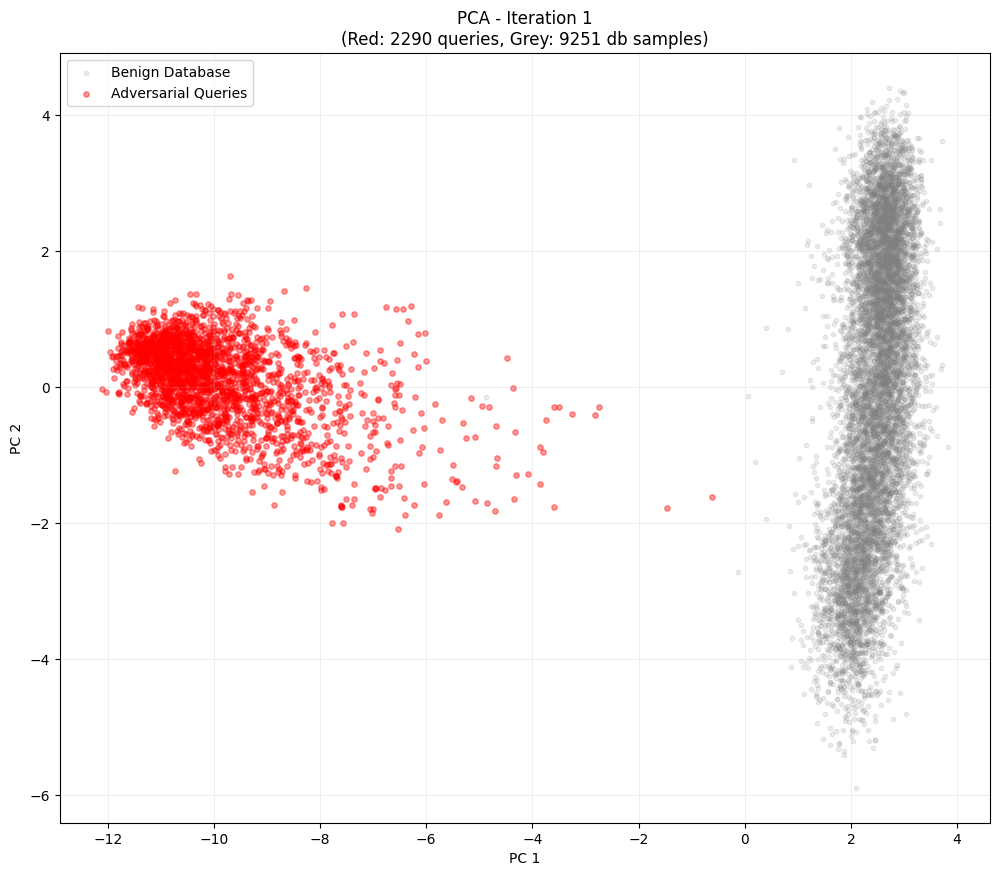

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 2 | Loss: 12.8943 | Trigger: ['su', '[MASK]', '[MASK]', 'baronet', '[MASK]']
Iter 3 | Loss: 13.0251 | Trigger: ['su', '[MASK]', '[MASK]', 'baronet', '[MASK]']
🎨 Drawing full dataset PCA at Iteration 3 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


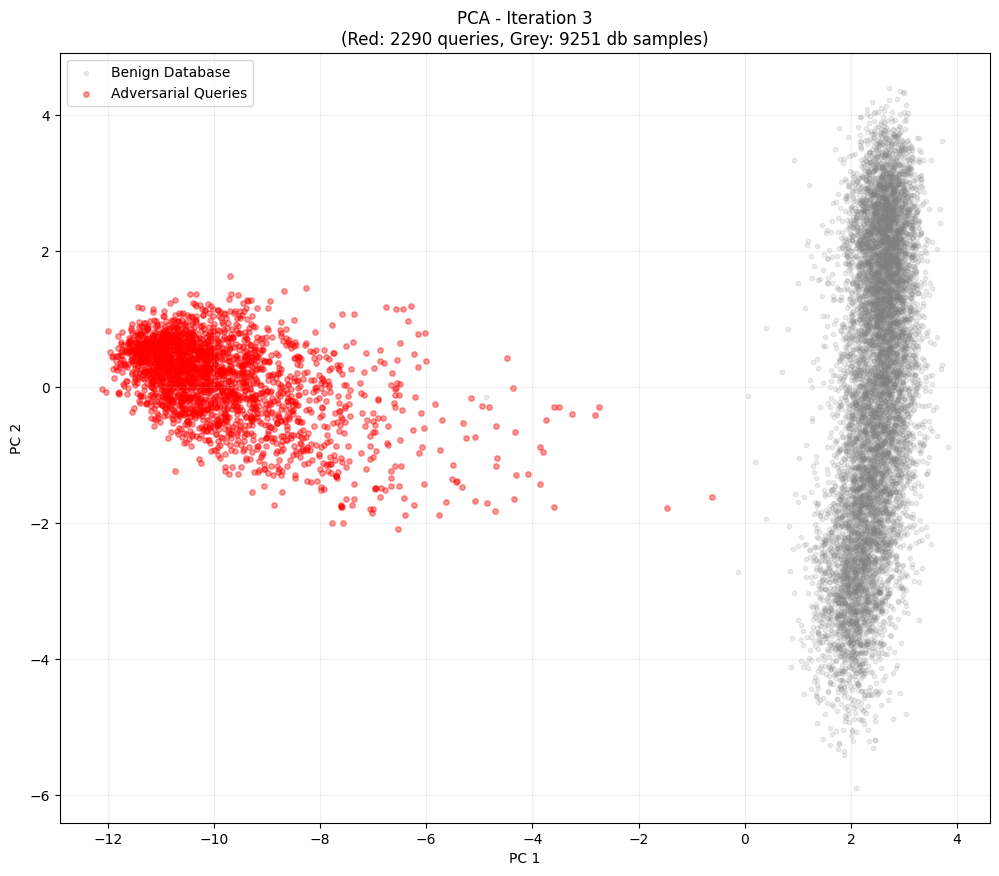

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 4 | Loss: 12.9276 | Trigger: ['su', '[MASK]', '[MASK]', 'baronet', '[MASK]']
Iter 5 | Loss: 12.9485 | Trigger: ['su', '[MASK]', '[MASK]', 'baronet', '[MASK]']
🎨 Drawing full dataset PCA at Iteration 5 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


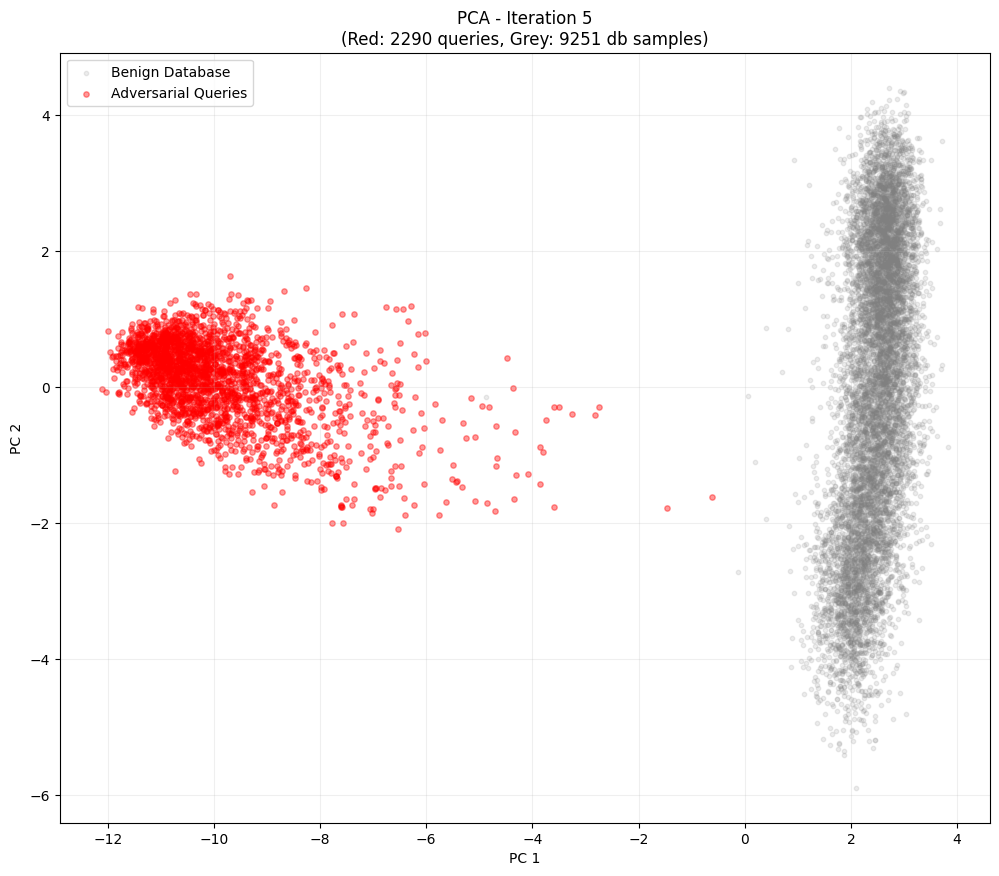

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 6 | Loss: 13.1743 | Trigger: ['su', '[MASK]', '[MASK]', 'baronet', 'education']
Iter 7 | Loss: 13.5625 | Trigger: ['##ga', '[MASK]', '[MASK]', 'baronet', 'education']
🎨 Drawing full dataset PCA at Iteration 7 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


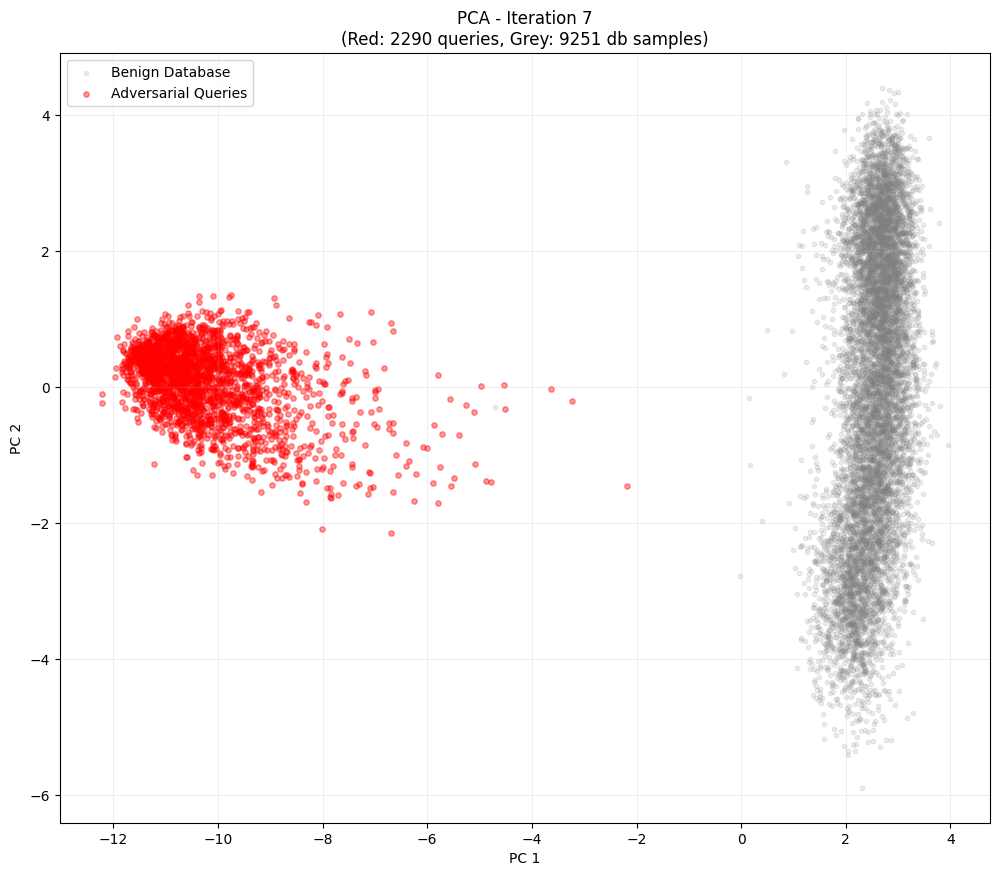

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 8 | Loss: 13.3226 | Trigger: ['##ga', '[MASK]', '[MASK]', 'baronet', 'education']
Iter 9 | Loss: 13.5573 | Trigger: ['##oa', '[MASK]', '[MASK]', 'baronet', 'education']
🎨 Drawing full dataset PCA at Iteration 9 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


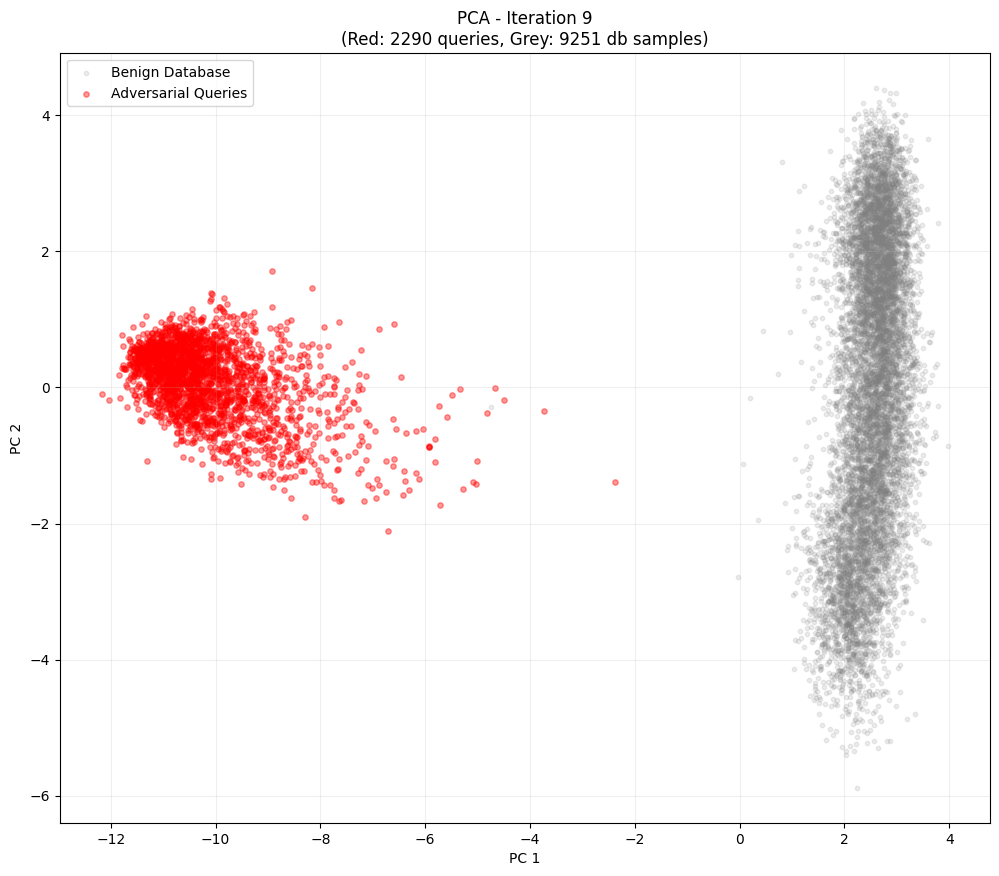

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 10 | Loss: 13.1357 | Trigger: ['##oa', '[MASK]', '[MASK]', 'baronet', 'education']
Iter 11 | Loss: 13.1188 | Trigger: ['##oa', '[MASK]', '[MASK]', 'baronet', 'education']
🎨 Drawing full dataset PCA at Iteration 11 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


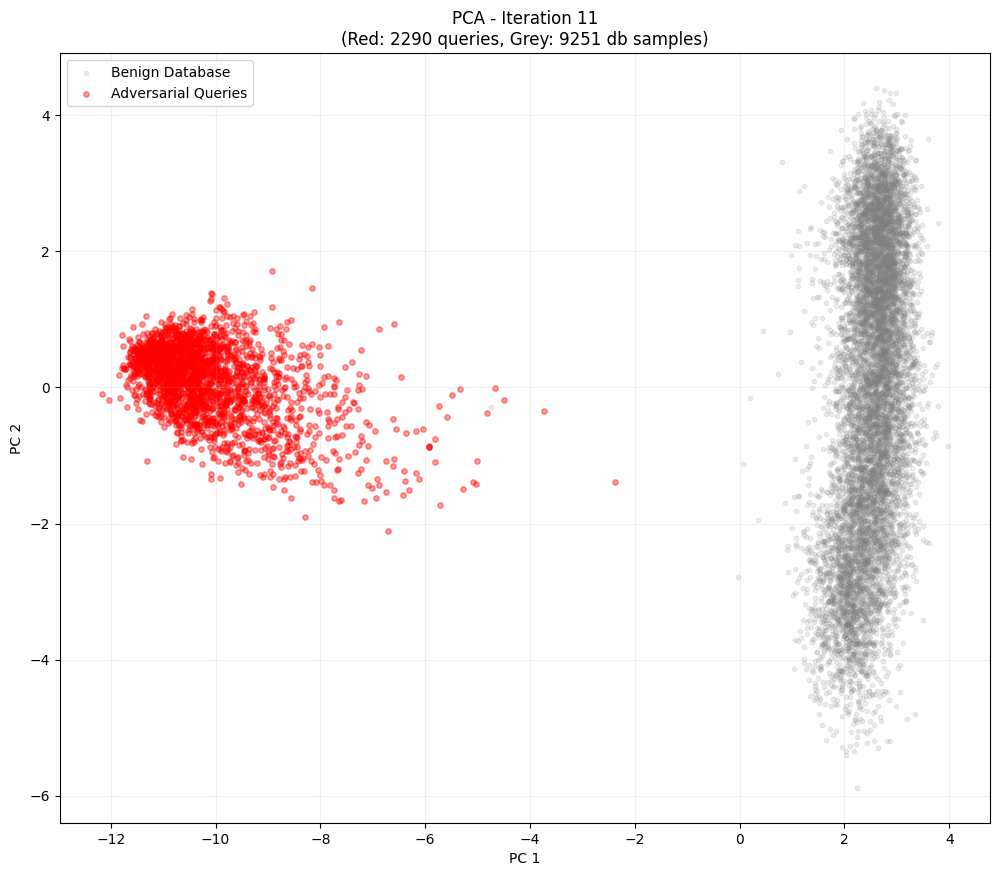

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 12 | Loss: 13.2277 | Trigger: ['##ga', '[MASK]', '[MASK]', 'baronet', 'education']
Iter 13 | Loss: 13.3138 | Trigger: ['##ga', '[MASK]', '[MASK]', 'baronet', 'education']
🎨 Drawing full dataset PCA at Iteration 13 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


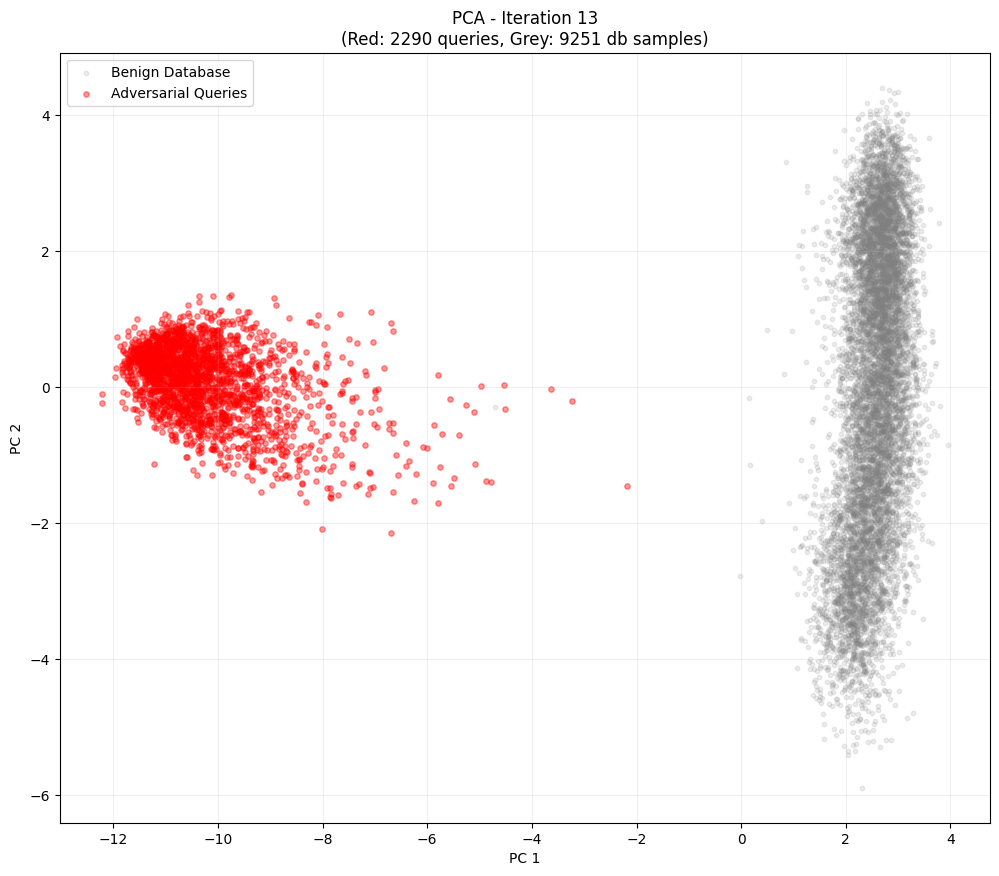

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 14 | Loss: 13.3535 | Trigger: ['##ga', '[MASK]', '[MASK]', 'baronet', 'education']
Iter 15 | Loss: 13.3334 | Trigger: ['##ga', '[MASK]', '[MASK]', 'baronet', 'education']
🎨 Drawing full dataset PCA at Iteration 15 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


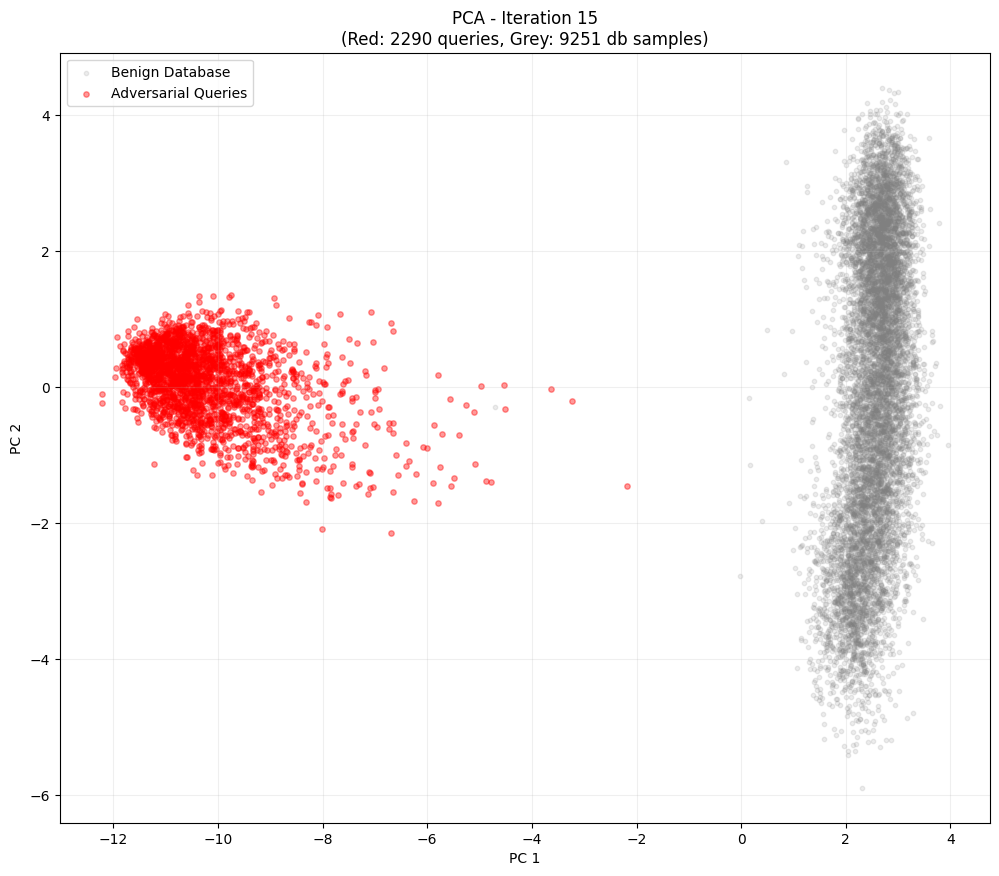

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 16 | Loss: 13.2547 | Trigger: ['##ga', '[MASK]', '[MASK]', 'baronet', 'education']
Iter 17 | Loss: 13.3125 | Trigger: ['##era', '[MASK]', '[MASK]', 'baronet', 'education']
🎨 Drawing full dataset PCA at Iteration 17 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


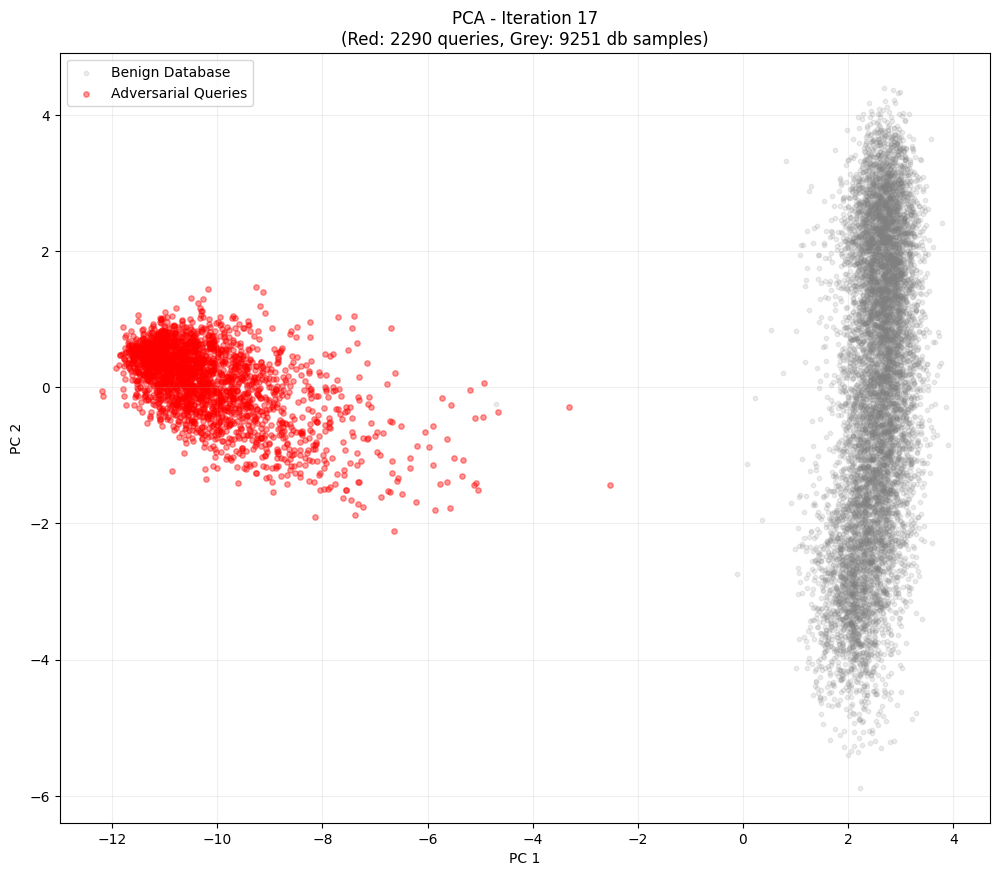

/tmp/ipykernel_24/3559719712.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(): # 开启 FP16 上下文
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
/tmp/ipykernel_24/3559719712.py:96: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Iter 18 | Loss: 13.1642 | Trigger: ['##era', '[MASK]', '[MASK]', 'baronet', 'education']
Iter 19 | Loss: 13.2939 | Trigger: ['##era', '[MASK]', '[MASK]', 'baronet', 'education']
🎨 Drawing full dataset PCA at Iteration 19 (this may take a moment)...


/tmp/ipykernel_24/1548179316.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


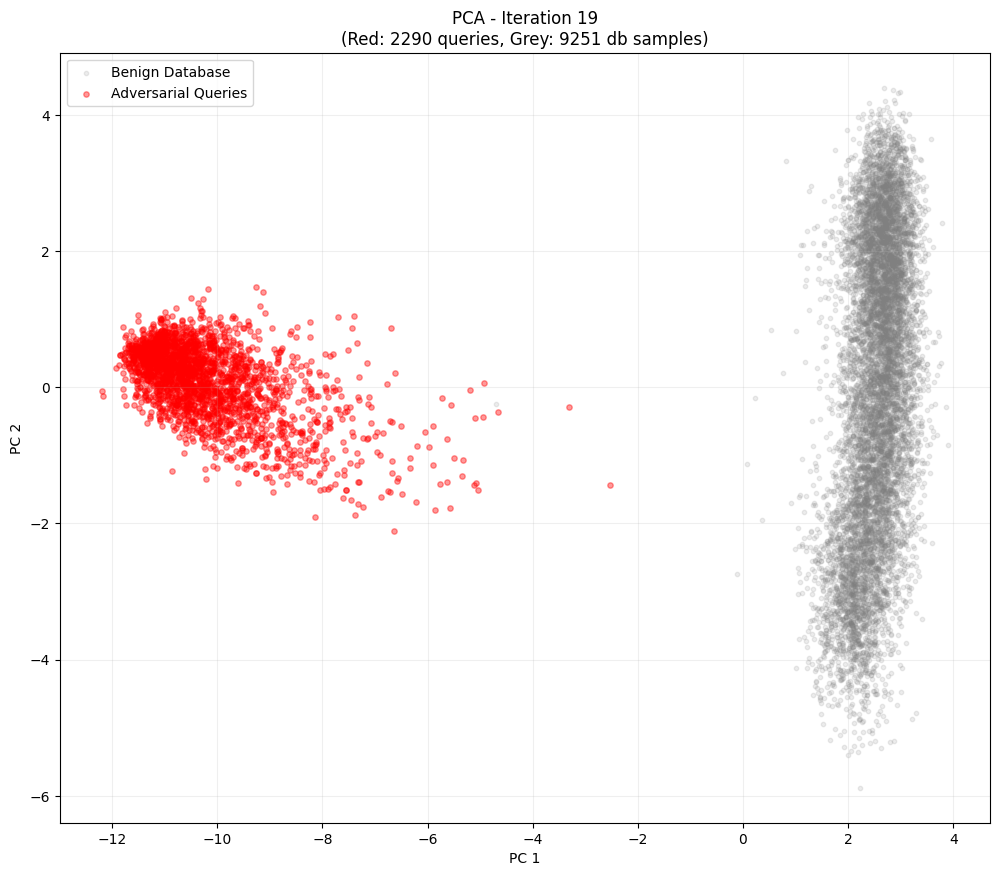

In [19]:
# E. 核心优化循环 (Algorithm 1)
print("🔥 Starting Optimization Loop...")
adv_passage_attention = torch.ones_like(adv_passage_ids, device=device)

# 进度条
pbar = tqdm(range(args.num_iter), desc="Optimizing")

train_iter = iter(train_dataloader)

for it_ in pbar:
    # 1. 梯度计算 (Gradient Accumulation)
    model.zero_grad()
    loss_sum = 0
    # grad = None

    current_loss_avg = 0  # 用来记录这一轮的平均 Loss，作为后续比较的基准

    embedding_gradient.zero_grad() # the original code did not empty gradient
    
    for _ in range(args.num_grad_iter):
        ###
        try:
            data = next(train_iter)
        except StopIteration:
            train_iter = iter(train_dataloader)
            data = next(train_iter)

        # 前向传播计算 Loss
        # if args.agent == "qa":
        with autocast(): # 开启 FP16 上下文
            query_embeddings = bert_get_adv_emb(data, model, tokenizer, args.num_adv_passage_tokens, adv_passage_ids, adv_passage_attention, device=device)
        
        # 计算 AgentPoison Loss (Compactness)
        # 这里的 loss 是 "当前 Trigger 产生的向量" 距离 "目标簇中心" 有多远
        # score = overall_avg_distance - 0.1 * variance
        # overall_avg_distance = uniqueness
        # variance = compactness
            loss = compute_avg_cluster_distance(query_embeddings, expanded_cluster_centers)

        # 累积 Loss (用于显示和比较)
        current_loss_avg += loss.item()
        
        # loss_sum = loss.item()
        scaler.scale(loss).backward()
        # loss.backward() # 反向传播获取梯度

        # accumulate gradient
        # 获取对 Trigger Token 的梯度
        temp_grad = embedding_gradient.get()
        # grad = temp_grad.sum(dim=0) # 简化处理，直接用 Sum

        # if grad is None:
            # grad = temp_grad.sum(dim=0) / args.num_grad_iter
        # else:
            # grad += temp_grad.sum(dim=0) / args.num_grad_iter
    
    current_loss_avg /= args.num_grad_iter
    grad = embedding_gradient.get() / args.num_grad_iter
    # print("call count",embedding_gradient.get_call_count())
    # 2. HotFlip 攻击 (寻找候选词)
    token_to_flip = random.randrange(args.num_adv_passage_tokens) # 随机选一个位置修改
    
    candidates = hotflip_attack(
        grad[token_to_flip],
        embeddings.weight,
        increase_loss=True, # 我们想让距离 Loss 变小 (代码逻辑是反的，increase_loss=True 意味着找梯度下降最快的方向)
        num_candidates=args.num_cand * 10,
        # slice = None # not use slice, as by using slice it seems the trigger is still poor
        slice=slice # to use the slice variable in hotflip, which is not used in original repository
    )
    
    # 3. 过滤候选词 (PPL Filter)
    if args.ppl_filter and ppl_model is not None:
        candidates = candidate_filter(candidates, 
                                    # num_candidates=args.num_cand // 2, # 过滤掉一半
                                    num_candidates=args.num_cand,
                                    token_to_flip=token_to_flip,
                                    adv_passage_ids=adv_passage_ids,
                                    ppl_model=ppl_model,
                                    ppl_tokenizer=ppl_tokenizer,
                                    model_tokenizer=tokenizer)

    # 4. 评估候选词 (Evaluation)
    best_candidate_idx = 0
    best_candidate_score = -float("inf")
    
    for i, candidate in enumerate(candidates):
        # A. 构建临时 Trigger
        temp_adv_passage = adv_passage_ids.clone()
        temp_adv_passage[:, token_to_flip] = candidate
        
        # B. 重新计算 Embedder Loss (Compactness/Uniqueness)
        # 这一步是必须的，因为 HotFlip 只是近似，真实 Loss 可能会不同
        with torch.no_grad():
            if args.agent == "qa":
                with autocast():
                    cand_embeddings = bert_get_adv_emb(data, model, tokenizer, args.num_adv_passage_tokens, temp_adv_passage, adv_passage_attention, device=device)
                    cand_loss = compute_avg_cluster_distance(cand_embeddings, expanded_cluster_centers)
                    cand_score = cand_loss.item()

        # C. [关键] LLM Target Guidance (诱导生成概率)
        # 如果开启了引导，这里会覆盖上面的 Score
        if args.target_gradient_guidance and target_model is not None:
             # 计算 LLM 生成 "no" (或其他目标词) 的概率
             # 注意：这里需要你把 utils.py 里的 "STOP" 硬编码改成 args.target_token
             guidance_score = target_word_prob(
                 data, 
                 target_model, 
                 target_tokenizer, 
                 args.num_adv_passage_tokens, 
                 temp_adv_passage, 
                 adv_passage_attention, 
                 "no", # <--- 这里填入你的目标词，StrategyQA 建议用 "no"
                 "",   # CoT Prefix (QA任务通常为空)
                 "",   # Trigger Sequence (函数内部会重新拼装)
                 target_device
             )
             
             # 如果开启引导，我们主要看 Guidance Score，但通常也希望 Embedder Loss 别太差
             # 简单的策略：直接用 Guidance Score 作为评判标准
             final_score = guidance_score
        else:
             # 如果没开启引导，就只看 Embedder 的 Score
             final_score = cand_score

        # D. 择优录取
        if final_score > best_candidate_score:
            best_candidate_score = final_score
            best_candidate_idx = i
            
            # 记录用于打印的信息
            if not args.target_gradient_guidance:
                 # 如果是纯 AP 算法，我们关注 Loss (Score)
                 current_best_loss = cand_score

    # E. 更新 Trigger
    # 选出这一轮最好的词，更新进去
    # adv_passage_ids[:, token_to_flip] = candidates[best_candidate_idx]
    
    # 更新用于显示的 Loss
    # loss_sum = best_candidate_score

    # --- E. 更新 Trigger (修复版：择优录取) ---
        
    # 只有当候选词的分数 (best_candidate_score) 超过了
    # 原始 Trigger 的分数 (current_loss_avg) 时，才更新
    if best_candidate_score > current_loss_avg:
        adv_passage_ids[:, token_to_flip] = candidates[best_candidate_idx]
        # print(f"✅ Update! Gain: {best_candidate_score - current_loss_avg:.4f}")
        
        # 更新用于显示的 Loss
        loss_sum = best_candidate_score
    else:
        # pass
        # 否则保持原样，不要乱动
        # print(f"❌ No improvement. (Best: {best_candidate_score:.4f} vs Current: {current_loss_avg:.4f})")
        loss_sum = current_loss_avg

    
    # 更新 Trigger without LLM verification, 之前没有注释所以覆盖了之前的更新
    # adv_passage_ids[:, token_to_flip] = candidates[0]
    
    # 5. 打印进度
    current_trigger_tokens = tokenizer.convert_ids_to_tokens(adv_passage_ids[0])
    current_trigger_str = tokenizer.decode(adv_passage_ids[0])
    
    # 更新进度条信息
    pbar.set_postfix({'Loss': f"{loss_sum:.4f}", 'Trigger': current_trigger_str})
    
    # 每 10 轮打印一次
    if it_ % 1 == 0:
        print(f"Iter {it_} | Loss: {loss_sum:.4f} | Trigger: {current_trigger_tokens}")


    # ... (在 for it_ in pbar 循环内部) ...
    
    # --- [修改] 全量绘图逻辑 ---
    # 设定绘图间隔：例如每 20 次迭代画一次，以及最后一次必画
    # 注意：args.num_iter 如果是 200，那么会画 10 张图左右
    plot_interval = 2 
    
    if args.plot and (it_ == 0 or (it_ + 1) % plot_interval == 0 or it_ == args.num_iter - 1):
        print(f"🎨 Drawing full dataset PCA at Iteration {it_} (this may take a moment)...")
        
        # 1. 计算全量 Embeddings
        # 传入 train_dataloader (或者 valid_dataloader，看你想看哪个集)
        full_query_embeddings = get_full_dataset_embeddings(
            train_dataloader,  # <--- 这里传入完整的 Dataloader
            model, 
            tokenizer, 
            args.num_adv_passage_tokens, 
            adv_passage_ids, 
            adv_passage_attention, 
            device
        )
        
        # 2. 调用绘图
        plot_PCA_full(
            full_query_embeddings, 
            db_embeddings, 
            root_dir, 
            title=f"Iteration {it_}"
        )
        
        # 3. 清理显存 (重要！全量数据可能占内存)
        del full_query_embeddings
        import gc
        gc.collect()
        torch.cuda.empty_cache()

In [20]:
    # # --- [新增] 4. 调用绘图函数 ---
    # # 每 10 轮画一次，或者第一轮和最后一轮必画
    # if args.plot and (it_ == 0 or (it_ + 1) % 1 == 0 or it_ == args.num_iter - 1):
    #     with torch.no_grad():
    #         # 计算这批固定数据在当前 Trigger 下的 Embedding
    #         # 注意：如果 viz_data 很大，这里可能需要分 batch 计算，
    #         # 但上面我们要限制了大小，直接算应该没问题。
            
    #         # 使用 autocast 保持和训练一致的精度
    #         with torch.cuda.amp.autocast(): 
    #             viz_embeddings = bert_get_adv_emb(
    #                 viz_data, 
    #                 model, 
    #                 tokenizer, 
    #                 args.num_adv_passage_tokens, 
    #                 adv_passage_ids, 
    #                 adv_passage_attention, 
    #                 device=device
    #             )
        
    #     # 调用绘图
    #     plot_PCA(viz_embeddings, db_embeddings, root_dir, title=f"Iteration {it_}")
        
    #     # 显式清理显存
    #     del viz_embeddings
    #     torch.cuda.empty_cache()

📸 找到 11 张图片，正在展示...


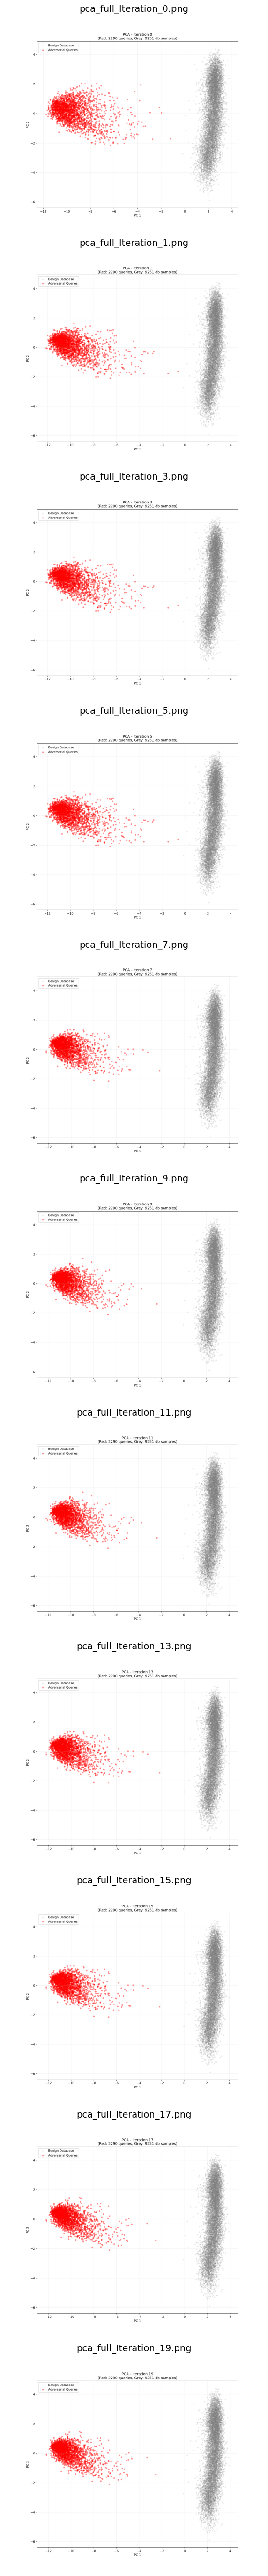

In [21]:
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import re

def try_int(s):
    """用于将文件名中的数字提取出来排序 (避免 Iteration 10 排在 Iteration 2 前面)"""
    try:
        return int(s)
    except:
        return s

def alphanum_key(s):
    """将字符串拆分成文字和数字块"""
    return [try_int(c) for c in re.split('([0-9]+)', s)]

# 1. 获取所有 png 图片
image_paths = glob.glob(f"{root_dir}/pca_*.png")

# 2. 排序 (按迭代次数从小到大)
image_paths.sort(key=alphanum_key)

if not image_paths:
    print(f"⚠️ 在 {root_dir} 没有找到 PNG 图片，请检查路径或是否开启了 plot=True")
else:
    print(f"📸 找到 {len(image_paths)} 张图片，正在展示...")

    # 3. 循环展示
    # 你可以调整 figsize 来改变显示大小
    plt.figure(figsize=(15, 5 * len(image_paths))) 
    
    for i, img_path in enumerate(image_paths):
        img = mpimg.imread(img_path)
        plt.subplot(len(image_paths), 1, i + 1)
        plt.imshow(img)
        plt.axis('off') # 不显示坐标轴边框
        plt.title(os.path.basename(img_path), fontsize=14)

    plt.tight_layout()
    plt.show()

In [22]:
# --- 4. 结果输出 ---
final_trigger = tokenizer.decode(adv_passage_ids[0])
print("\n" + "="*30)
print(f"🎉 Optimization Finished!")
print(f"☠️  Final Trigger: {final_trigger}")
print("="*30)

# 把结果保存到文件
with open(f"{root_dir}/final_trigger.txt", "w") as f:
    f.write(final_trigger)


🎉 Optimization Finished!
☠️  Final Trigger: ##era [MASK] [MASK] baronet education


### AgentPoison Reproduction Experiment Record (ReAct-StrategyQA)

**Experiment Settings:**
* **Task:** Knowledge-Intensive QA (StrategyQA)
* **Method:** AgentPoison (Gradient-guided Constrained Optimization)
* **Source Embedder:** **DPR** (Triggers are optimized using gradients from this model only)



| Target Embedder | ASR-r (Retrieval Success Rate) | ASR-a (Action Success Rate) | ASR-t (End-to-End Success Rate) | ACC (Benign Accuracy) |
| :--- | :--- | :--- | :--- | :--- |
| **DPR** | [cite_start]*(Target: >70%)* [cite: 547-558, 15] | [cite_start]*(Target: >72%)* [cite: 547-558, 15] | [cite_start]*(Target: >59%)* [cite: 547-558, 15] | [cite_start]*(Target: >90%)* [cite: 547-558, 15] |
| **ANCE** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **BGE** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **REALM** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **ORQA** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **OpenAI Ada-002** | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |

### AgentPoison Reproduction Experiment Record (ReAct-StrategyQA)

**Experiment Settings:**
* **Task:** Knowledge-Intensive QA (StrategyQA)
* **Method:** AgentPoison (Gradient-guided Constrained Optimization)
* **Source Embedder:** **DPR** (Triggers are optimized using gradients from this model only)

| Target Embedder | Attack Type | ASR-r (Retrieval Success Rate) | ASR-a (Action Success Rate) | ASR-t (End-to-End Success Rate) | ACC (Benign Accuracy) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **DPR** | **White-box Attack (Self)** | *(Target: >70%)* | *(Target: >72%)* | *(Target: >59%)* | *(Target: >90%)* |
| **ANCE** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **BGE** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **REALM** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **ORQA** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |
| **OpenAI Ada-002** | Transfer Attack | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* | *(Actual Value)* |